# How to load a dataset
This notebook demonstrates how to load datasets in different ways.

In [1]:
from histokit.data import Dataset

icaird_cervical_dataset = Dataset.from_index(
    "../data/icaird/cervical/index.csv",
    "../data/icaird/cervical/labels.json",
)

In [2]:
from histokit.data import Dataset

camelyon16_dataset = Dataset.from_index(
    "../data/camelyon16/index.csv",
    "../data/camelyon16/labels.json",
)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def show_image(img, cmap=None, dpi=100):
    if isinstance(img, Image.Image):
        img = np.asarray(img)

    h, w = img.shape[:2]

    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])  # fill entire figure

    ax.imshow(img, cmap=cmap, interpolation="nearest")
    ax.set_axis_off()

    plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def show_label_mask_pixel_perfect(mask):
    h, w = mask.shape
    dpi = 100

    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])

    ax.imshow(mask, interpolation="nearest")
    ax.set_axis_off()

    plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from PIL import Image


def show_image_with_label_mask(
    img,
    mask: np.ndarray,
    label_map: dict[str, int],
    background_label: str = "background",
    alpha: float = 0.4,
    dpi: int = 100,
):
    if isinstance(img, Image.Image):
        img = np.asarray(img)

    if img.ndim != 3:
        raise ValueError(f"img must have shape (H, W, 3), got {img.shape}")

    if mask.ndim != 2:
        raise ValueError(f"mask must have shape (H, W), got {mask.shape}")

    if img.shape[:2] != mask.shape:
        raise ValueError(
            f"img and mask must have matching spatial shape, got "
            f"{img.shape[:2]} and {mask.shape}"
        )

    h, w = mask.shape

    label_items = sorted(label_map.items(), key=lambda x: x[1])
    label_ids = [v for _, v in label_items]
    max_id = max(label_ids)

    base_cmap = plt.get_cmap("tab20")
    colors = [base_cmap(i % 20) for i in range(max_id + 1)]

    if background_label in label_map:
        bg_id = label_map[background_label]
        r, g, b, _ = colors[bg_id]
        colors[bg_id] = (r, g, b, 0.0)

    cmap = ListedColormap(colors)
    bounds = np.arange(max_id + 2) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)

    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])

    ax.imshow(img, interpolation="nearest")
    ax.imshow(mask, cmap=cmap, norm=norm, interpolation="nearest", alpha=alpha)

    ax.set_axis_off()
    plt.show()

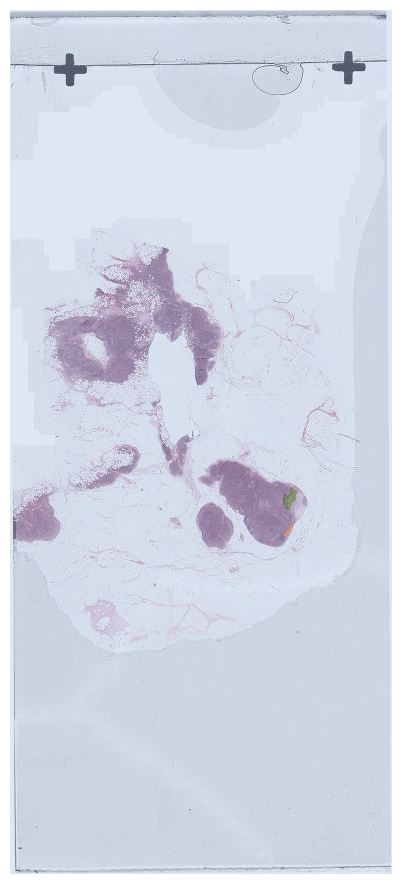

In [10]:
LEVEL = 8

for sample in camelyon16_dataset.samples():
    with sample.open_slide() as slide:
        thumbnail = slide.get_thumbnail(LEVEL)
        downsample = slide.level_downsamples[LEVEL]

    annotations = sample.make_annotations()
    label_mask = annotations.render(thumbnail.shape[:2], downsample)

    show_image_with_label_mask(
        thumbnail,
        label_mask,
        sample.annotation_schema.label_map,
        alpha=0.4,
    )